# Analyses of syllables

In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1"
from joblib import Parallel, delayed
import time
import jax
from jax import devices
import jax.numpy as jnp
import jax.random as jr
from scipy.stats import zscore
import jax.numpy as jnp
import jax.random as jr
from collections import defaultdict
import gc
from dynamax.hidden_markov_model import LinearAutoregressiveHMM, PoissonHMM
from dynamax.hidden_markov_model import PoissonHMM 

# Get my functions
from functions import idxs_from_files, cross_validate_poismodel, cross_validate_armodel, compute_inputs

ERROR:2026-03-02 15:43:37,517:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


In [3]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --Machine learning and statistics
from scipy.stats import zscore
from scipy import stats

# Get my functions
from functions import idxs_from_files
from one.api import ONE
one = ONE(mode='remote')

In [4]:
# LOAD DATA
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'
all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

## Fit HMM with filtered whisker ME

In [5]:
from scipy.signal import butter, filtfilt

def lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)


def low_pass(signal, cutoff, sf):    
    not_nan = signal[np.where(~np.isnan(signal))]
    low_pass = lowpass_filter(not_nan, cutoff, fs=sf, order=4)
    signal[np.where(~np.isnan(signal))] = low_pass
    return signal

In [6]:
def wheel_over_wavelet_clusters(init, inter, original_design_matrix, session_trials, most_likely_states):
    
    plot_min = -10
    plot_max = 10
    frame_rate = 60

    fig, ax = plt.subplots(ncols=1 , nrows=1, sharex=False, sharey=False, figsize=[20, 5])
    plt.rc('font', size=12)
    plot_var = 'whisker_me'
    # ax.plot(data)
    ax.plot(stats.zscore(original_design_matrix.loc[original_design_matrix['Bin']>=init, plot_var].reset_index()[plot_var], nan_policy='omit'), color='black')
    # ax.plot(stats.zscore(empirical_data.loc[empirical_data['Bin']>=init, 'l_paw_x'].reset_index()['l_paw_x'], nan_policy='omit'), color='blue', label='Left paw')
    # ax.plot(stats.zscore(empirical_data.loc[empirical_data['Bin']>=init, 'r_paw_x'].reset_index()['r_paw_x'], nan_policy='omit'), color='red', label='Right paw')

    ax.imshow(np.concatenate([most_likely_states])[None,:],
                extent=(0, len(np.concatenate([most_likely_states])), -10, 10),
                aspect="auto",
                cmap='Set2',
                alpha=0.6)
    
    # ax.vlines(np.array(session_trials['goCueTrigger_times'] -init)*frame_rate, plot_min, plot_max, label='Stim On', 
    #             color='Black', linewidth=2)
    # ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==1, 'feedback_times'] * frame_rate)-init*frame_rate, 
    #             plot_min, plot_max, label='Correct', color='Green', linewidth=2, linestyle='dashed')
    # ax.vlines(np.array(session_trials.loc[session_trials['feedbackType']==-1, 'feedback_times'] * frame_rate)-init*frame_rate, 
    #             plot_min, plot_max, label='Incorrect', color='Red', linewidth=2, linestyle='dashed')
    # ax.vlines(np.array(session_trials['firstMovement_times'] * frame_rate)-init*frame_rate, plot_min, plot_max, label='First movement', color='cyan')
    # ax.vlines(np.array(session_trials['intervals_0'] * frame_rate)-init*frame_rate, plot_min, plot_max, label='Trial end', color='Grey', linewidth=2)
    # ax.vlines(np.array((session_trials['goCueTrigger_times'] - session_trials['quiescencePeriod']) * frame_rate)-init*frame_rate, 
    #             plot_min, plot_max, label='Quiescence start', color='Pink', linewidth=2)
    
    ax.set_xlim([0, inter])
    ax.set_ylim([-10, 10])

    ax.set_ylabel("Wheel velocity")
    ax.set_xlabel("Time (s)")

    ax.set_xticks(np.arange(0, inter, inter/5), np.round(np.arange(0, inter/frame_rate, (inter/frame_rate)/5)))
    ax.set_title("Wavelet transform clusters")
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_ylim([-10, 10])
    ax.set_ylim([-5, 10])

    plt.tight_layout()    
    plt.show()

In [71]:
from scipy.signal import spectrogram
def plot_spectrogram(signal):
    # Example signal (remove this if you already have your own)
    fs = 60  # sampling rate (Hz)
    # t = np.arange(0, 5, 1/fs)
    # signal = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*40*t)

    # Compute spectrogram
    frequencies, times, Sxx = spectrogram(
        signal,
        fs=fs,
        window='hann',
        nperseg=int(fs * 2),      # 2-second window
        noverlap=int(fs * 1.5)
        detrend=False,
        scaling='density',
        mode='psd'
    )

    # Convert power to dB
    Sxx_dB = 10 * np.log10(Sxx + 1e-12)
    Sxx_norm = (Sxx_dB - Sxx_dB.mean(axis=1, keepdims=True)) / \
            Sxx_dB.std(axis=1, keepdims=True)
    # Plot
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(times, frequencies, Sxx_norm, shading='gouraud')
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.title('Spectrogram')
    plt.colorbar(label='Power (dB)')
    plt.ylim(0, 30)  # Adjust depending on your frequency range of interest
    plt.xlim(0, 2000)  # Adjust depending on your frequency range of interest
    plt.tight_layout()
    plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2122045444.py, line 14)

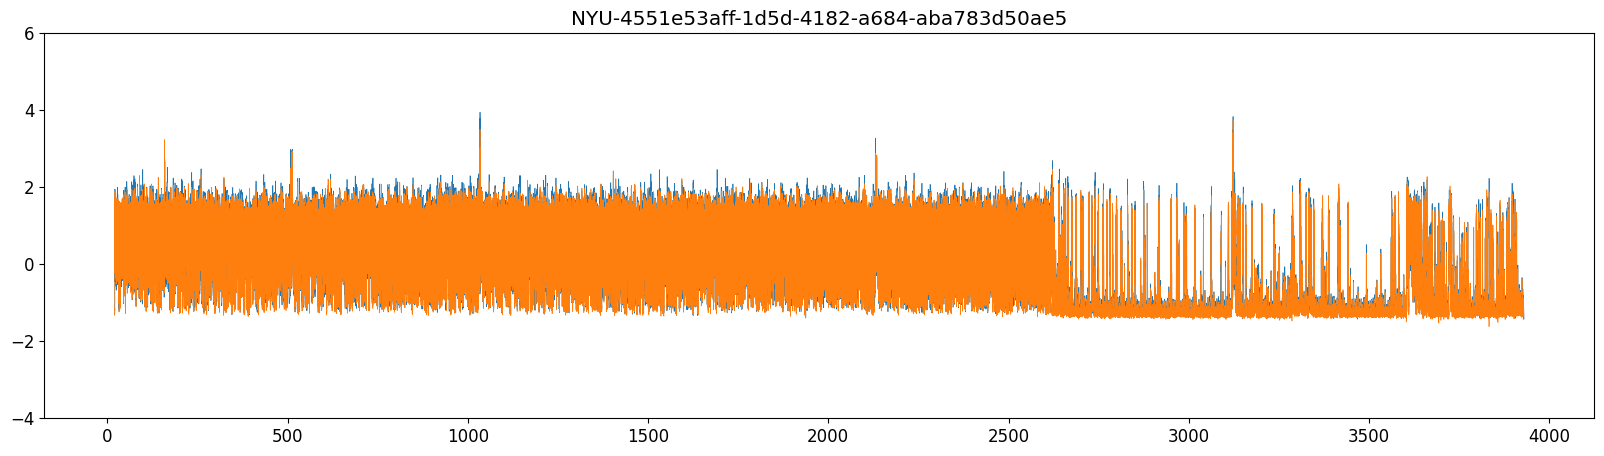

51e53aff-1d5d-4182-a684-aba783d50ae5


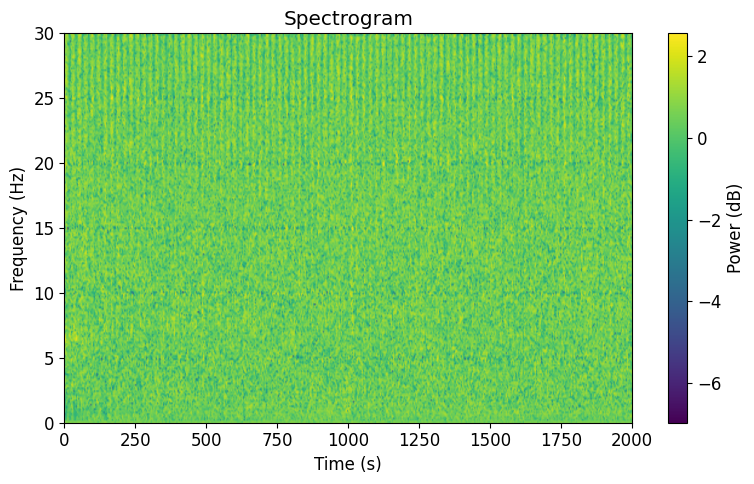

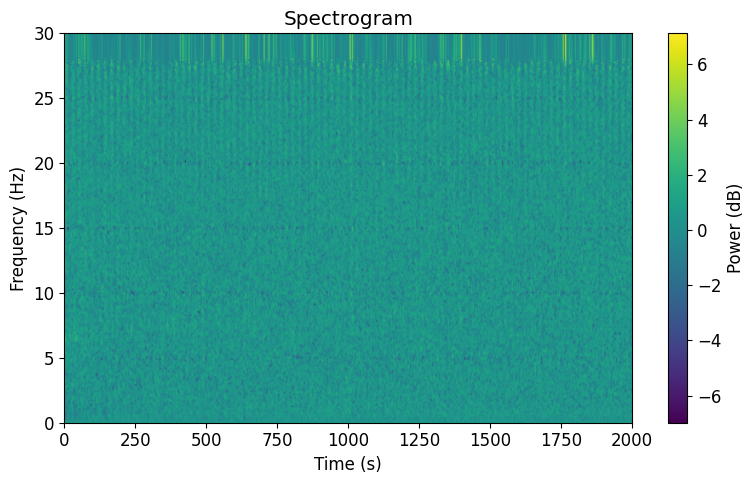

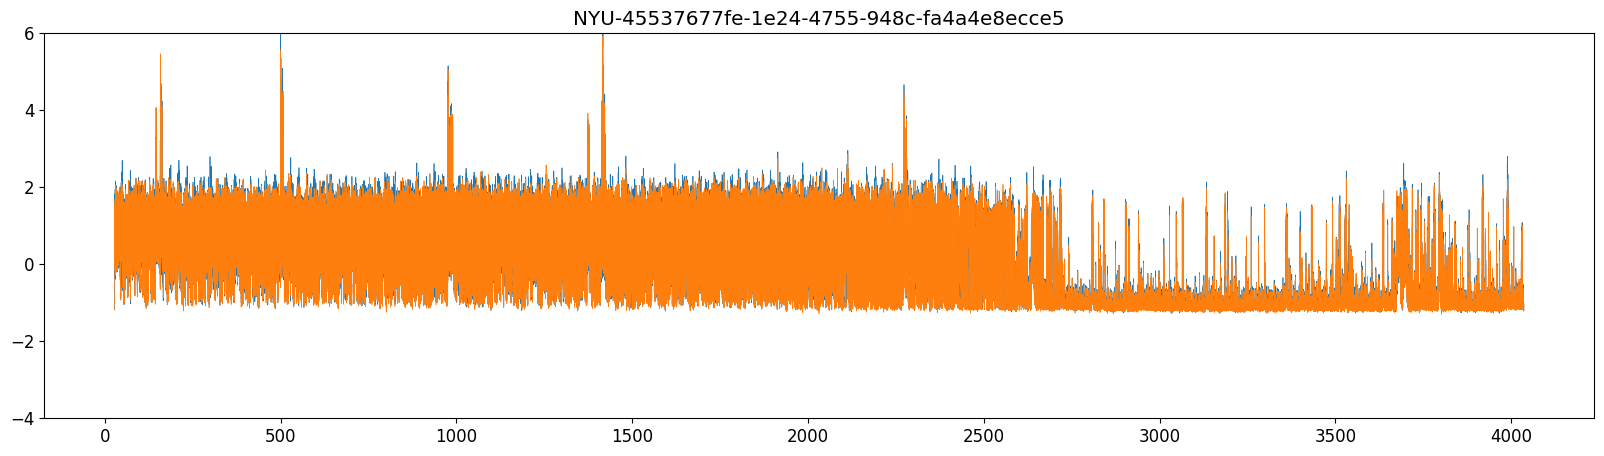

537677fe-1e24-4755-948c-fa4a4e8ecce5


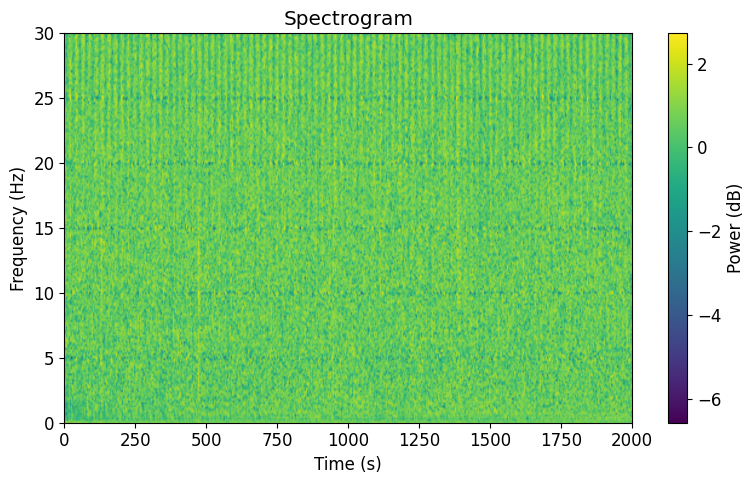

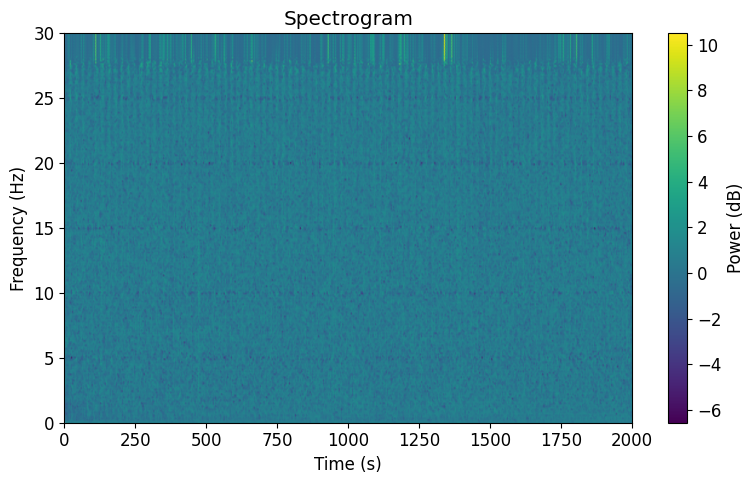

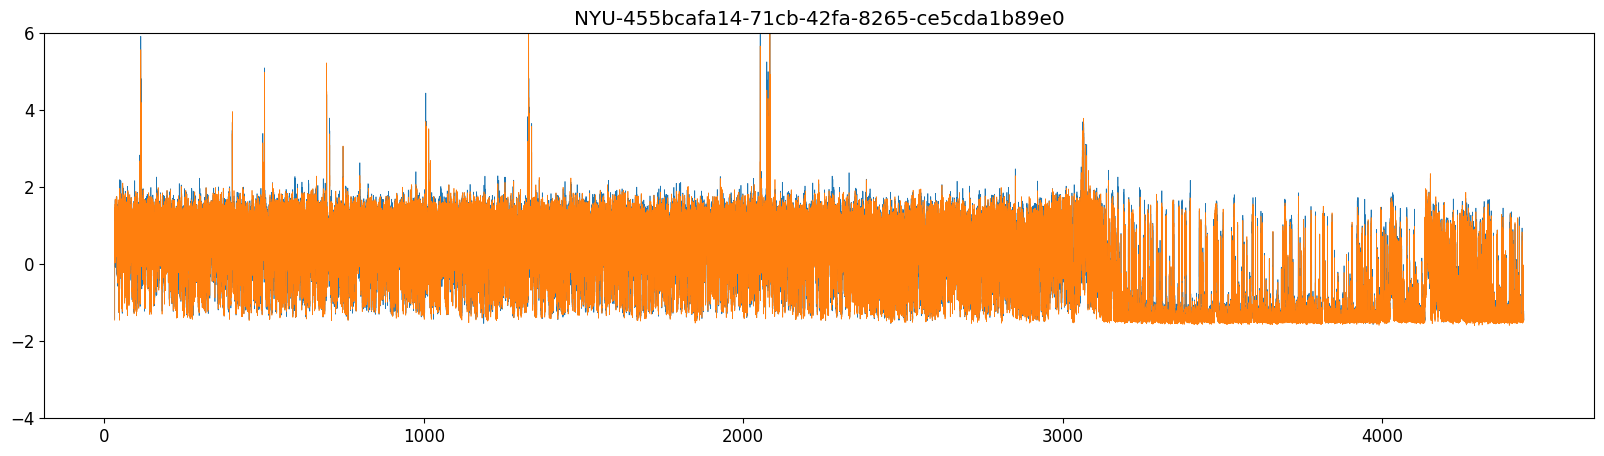

5bcafa14-71cb-42fa-8265-ce5cda1b89e0


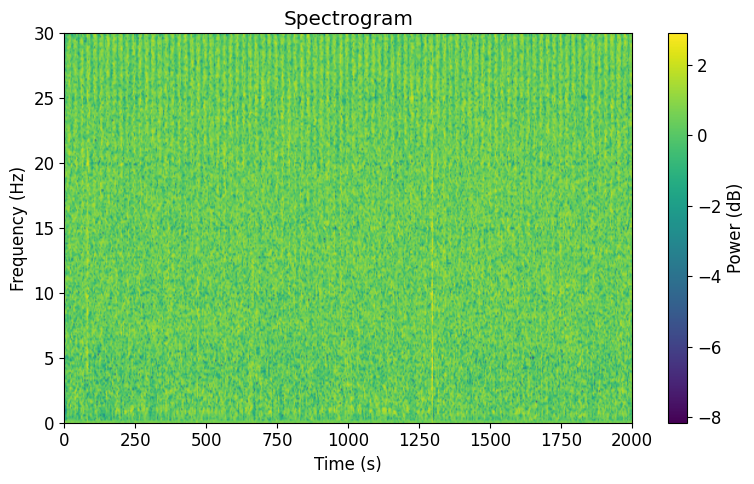

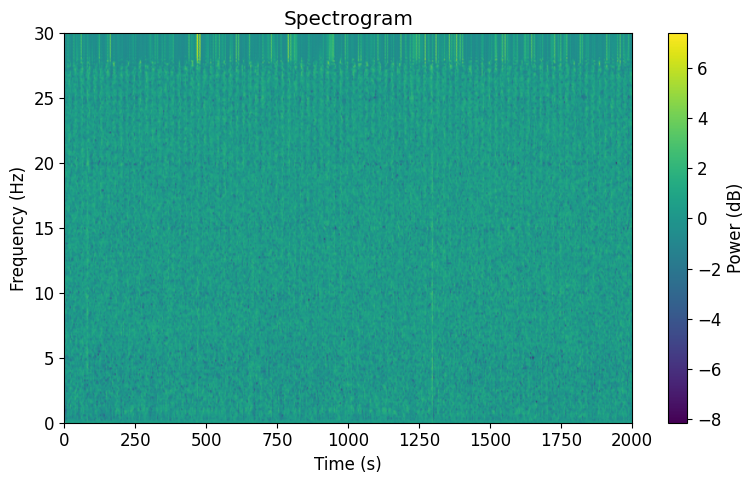

In [72]:
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'

for s, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]

    # mouse_name = 'PL017'
    # session = '1b61b7f2-a599-4e40-abd6-3e758d2c9e25'
    # mouse_name = 'NR_0020'
    # session = 'd901aff5-2250-467a-b4a1-0cb9729df9e2'
    # session = 'eacc49a9-f3a1-49f1-b87f-0972f90ee837'
    # mouse_name = 'NYU-40'
    # session = '8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8'
    # if mouse_name in ['PL017', 'PL034', 'NR_0020', 'UCLA017', 'UCLA034', 'UCLA035', 'NYU-39', 'NYU-40', 'NYU-45', 'NYU-46']:
    if mouse_name in ['NYU-45']:
        trials_file = data_path + "session_trials_" + str(session) + '_'  + mouse_name
        session_trials = pd.read_parquet(trials_file, engine='pyarrow').reset_index() 
        matrix_file = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
        design_matrix = pd.read_parquet(matrix_file, engine='pyarrow').reset_index() 
        filtered = low_pass(np.array(design_matrix['whisker_me']), cutoff=20, sf=60)
        design_matrix['filtered'] = filtered
        fig, ax = plt.subplots(figsize=[20, 5])
        plt.plot(design_matrix['Bin'], zscore(design_matrix['whisker_me'], axis=0, nan_policy='omit'), linewidth=.5)
        plt.plot(design_matrix['Bin'], zscore(design_matrix['filtered'], axis=0, nan_policy='omit'), linewidth=.5)
        # plt.xlim([500, 550])
        plt.ylim([-4, 6])
        plt.title(mouse_name +session)
        plt.show()
        print(session)
        plot_spectrogram(design_matrix['whisker_me'])
        plot_spectrogram(design_matrix['filtered'])
        


In [10]:
mouse_name = 'NYU-45'
session = '5bcafa14-71cb-42fa-8265-ce5cda1b89e0'

In [45]:
num_train_batches = 5
state = 2
lag = 1
kappa = 10
method='prior'
fit_method='em'

matrix_file = data_path + "design_matrix_" + str(session) + '_'  + mouse_name
original_design_matrix = pd.read_parquet(matrix_file, engine='pyarrow').reset_index() 
filtered = low_pass(np.array(original_design_matrix['whisker_me']), cutoff=15, sf=60)
original_design_matrix['filtered'] = filtered

var_interest = ['avg_whisker_me']
var_interest = ['whisker_me']
var_interest = ['filtered']

# Zscore if needed (paws)
array_matrix = zscore(np.array(original_design_matrix), axis=0, nan_policy='omit')

# Remove NaNs
filtered_matrix = array_matrix[~np.isnan(array_matrix).any(axis=1)]
keys = np.where(original_design_matrix.keys().isin(var_interest))
design_matrix = filtered_matrix[:, keys] 

design_matrix = np.reshape(design_matrix,(np.shape(design_matrix)[0], np.shape(design_matrix)[2]))
# Prepare data
num_timesteps = np.shape(design_matrix)[0]
emission_dim = np.shape(design_matrix)[1]
shortened_array = np.array(design_matrix[:(num_timesteps // num_train_batches) * num_train_batches])
train_emissions = jnp.stack(jnp.split(shortened_array, num_train_batches))

test_arhmm = LinearAutoregressiveHMM(state, emission_dim, num_lags=lag, transition_matrix_stickiness=kappa)
my_inputs = compute_inputs(shortened_array, lag, emission_dim)
train_inputs = jnp.stack(jnp.split(my_inputs, num_train_batches))

all_val_lls, fit_params, init_params, baseline_lls = cross_validate_armodel(
        test_arhmm, jr.PRNGKey(0), train_emissions, train_inputs, method, num_train_batches, fit_method)

# Find parameters for best fold
initial_probs = fit_params[0].probs[0]
transition_matrix = fit_params[1].transition_matrix[0]
emission_weights = fit_params[2].weights[0]
emission_biases = fit_params[2].biases[0]
emission_covariances = fit_params[2].covs[0]

# Initialize new hmm
new_arhmm = LinearAutoregressiveHMM(state, emission_dim, num_lags=lag, transition_matrix_stickiness=kappa)
best_fold_params, props = new_arhmm.initialize(key=jr.PRNGKey(0), method=method,
                                initial_probs=initial_probs,
                                transition_matrix=transition_matrix,
                                emission_weights=emission_weights,
                                emission_biases=emission_biases,
                                emission_covariances=emission_covariances,
                                emissions=shortened_array)  # not sure if I need to include

# Get state estimates for validation data
most_likely_states = new_arhmm.most_likely_states(best_fold_params, shortened_array, my_inputs)

In [46]:
init = 120000
inter = 5000

/tmp/ipykernel_23227/914278818.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(1, 1))


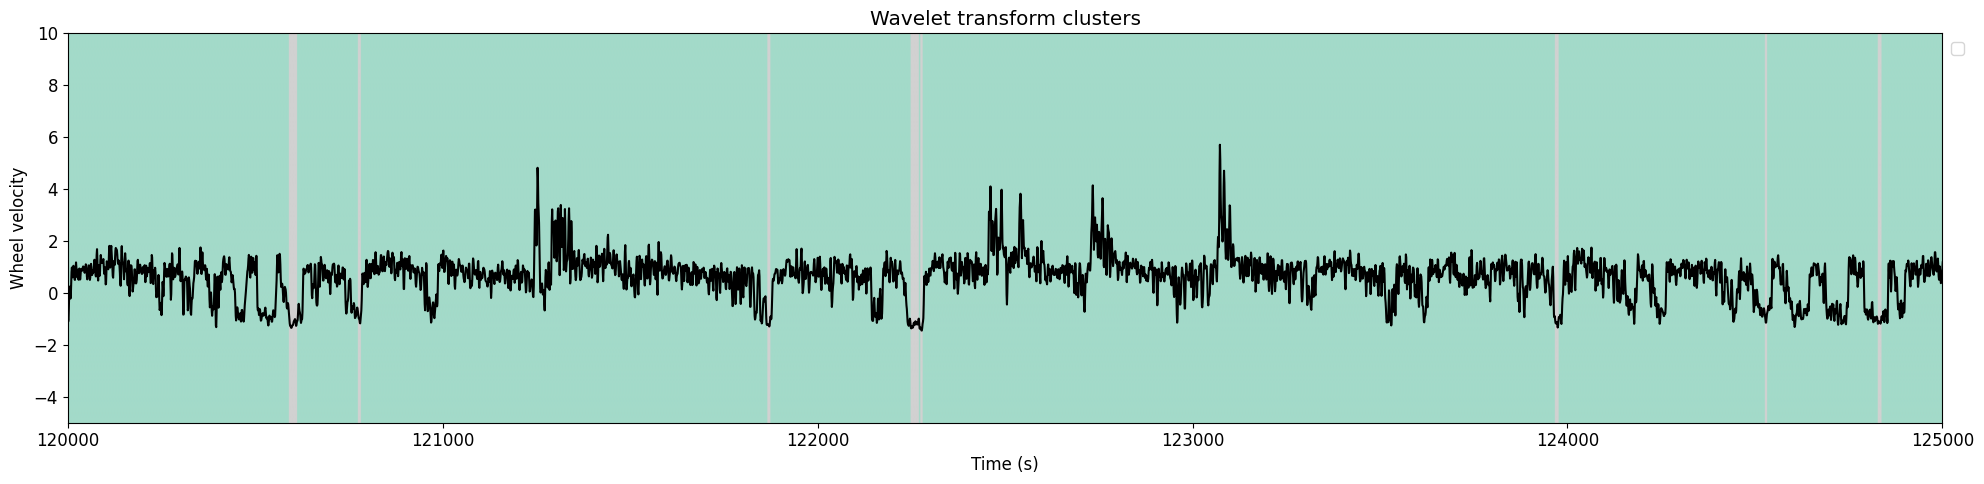

In [47]:
    plot_min = -10
    plot_max = 10
    frame_rate = 60

    fig, ax = plt.subplots(ncols=1 , nrows=1, sharex=False, sharey=False, figsize=[20, 5])
    plt.rc('font', size=12)
    plot_var = 'whisker_me'
    # ax.plot(data)
    ax.plot(filtered_matrix[:, keys[0][0]], color='black')
    # ax.plot(stats.zscore(empirical_data.loc[empirical_data['Bin']>=init, 'l_paw_x'].reset_index()['l_paw_x'], nan_policy='omit'), color='blue', label='Left paw')
    # ax.plot(stats.zscore(empirical_data.loc[empirical_data['Bin']>=init, 'r_paw_x'].reset_index()['r_paw_x'], nan_policy='omit'), color='red', label='Right paw')

    ax.imshow(np.concatenate([most_likely_states])[None,:],
                extent=(0, len(np.concatenate([most_likely_states])), -10, 10),
                aspect="auto",
                cmap='Set2',
                alpha=0.6)
    

    ax.set_xlim([init, init+inter])
    ax.set_ylim([-10, 10])

    ax.set_ylabel("Wheel velocity")
    ax.set_xlabel("Time (s)")

    # ax.set_xticks(np.arange(0, inter, inter/5), np.round(np.arange(0, inter/frame_rate, (inter/frame_rate)/5)))
    ax.set_title("Wavelet transform clusters")
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_ylim([-10, 10])
    ax.set_ylim([-5, 10])

    plt.tight_layout()    
    plt.show()

/tmp/ipykernel_23227/2811580878.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(1, 1))


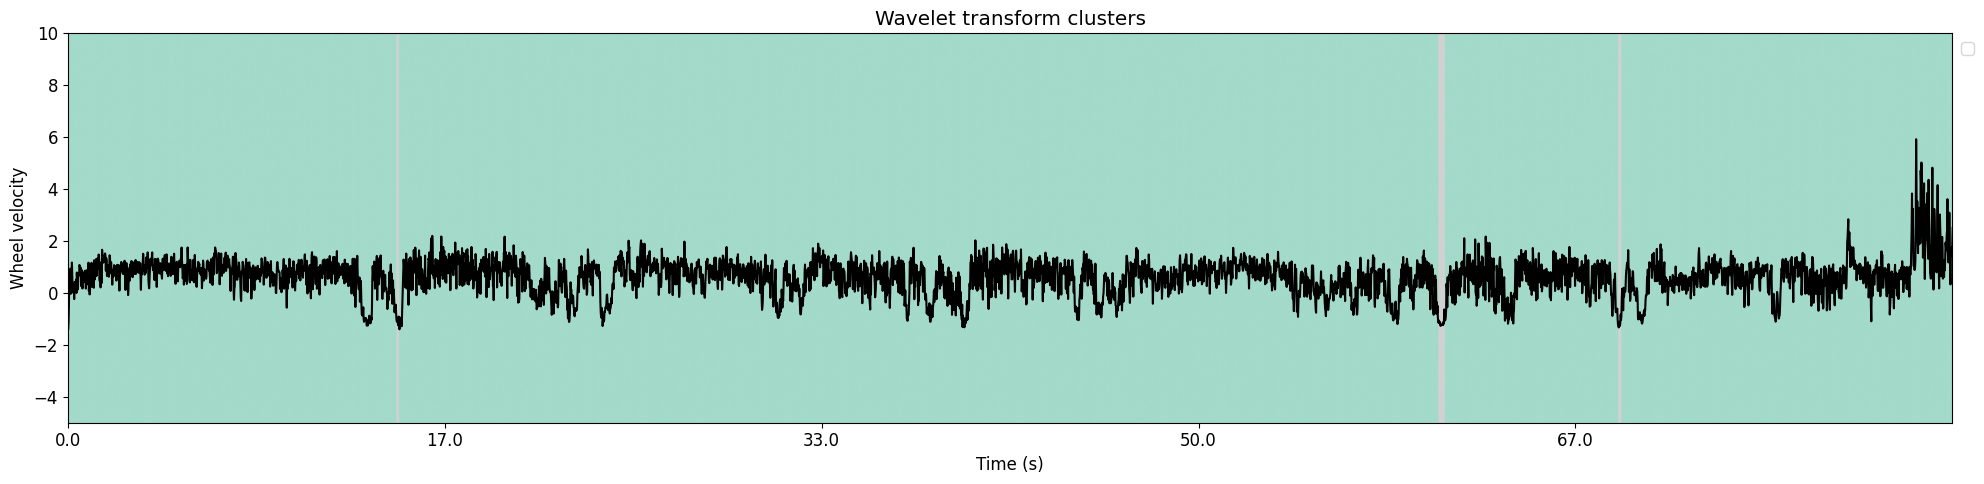

In [35]:

empirical_data = original_design_matrix.copy()
wheel_over_wavelet_clusters(init, inter, empirical_data, session_trials, most_likely_states)